In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.diffeomorphisms.fixed_origin import FixedOriginDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problem_solver.encoder_decoder.deformed_anisotropic_gaussian.unstructured import UnstructuredDeformedGaussianSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.nn.module.polynomial_activation import PolynomialActivation
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.polynomial_parity import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

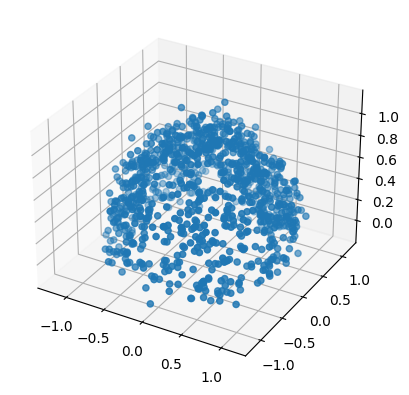

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
    def adjoint_forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Create the feed forward model
def create_feed_forward_model(in_dim, out_dim, n_layers, hidden_dim=16):
    layers = []
    layers.append(nn.Linear(in_dim, hidden_dim))
    layers.append(nn.ReLU())
    for _ in range(n_layers - 2):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(hidden_dim, out_dim))
    
    return nn.Sequential(*layers)


In [6]:
class SubstractEncoder(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y):
        return y - torch.tensor([0,0,1])

In [7]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 4
flow = create_flow_model(dim, n_flows, 2)
phi_ = NFlowVectorDiffeomorphism(dim, flow)
origin = torch.tensor([0.,0.,1.])
phi = FixedOriginDiffeomorphism(phi_, origin)

l2_weight = 0.

n_layers = 4
encoder = create_feed_forward_model(dim, dim, n_layers)
# encoder = SubstractEncoder()

model = UnstructuredDeformedGaussianSolver(forward, phi, l2_weight, encoder).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, l1_weight):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            # Compute regularization on polynomial coefficients
            l1_norm_phi = 0
            for module in phi.phi.diffeo.modules():
                if isinstance(module, PolynomialParityTransform):
                    # Access the CNN submodule containing activation layers
                    for submodule in module.modules():
                        if isinstance(submodule, PolynomialActivation):
                            if hasattr(submodule, 'coefficients'):
                                # Sum absolute values of polynomial coefficients
                                l1_norm_phi += torch.sum(torch.abs(submodule.coefficients))
            loss += l1_weight * l1_norm_phi

            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")
        # print(model.psi.diagonal)

In [9]:
# Train the model
n_epochs = 100
l1_weight = 0.01
train(model, train_loader, optimizer, n_epochs, l1_weight)

Epoch 1/100, Loss: 0.5684
Epoch 2/100, Loss: 0.5543
Epoch 3/100, Loss: 0.5399
Epoch 4/100, Loss: 0.5227
Epoch 5/100, Loss: 0.4989
Epoch 6/100, Loss: 0.4646
Epoch 7/100, Loss: 0.4177
Epoch 8/100, Loss: 0.3636
Epoch 9/100, Loss: 0.3170
Epoch 10/100, Loss: 0.2841
Epoch 11/100, Loss: 0.2438
Epoch 12/100, Loss: 0.2120
Epoch 13/100, Loss: 0.2051
Epoch 14/100, Loss: 0.1996
Epoch 15/100, Loss: 0.1954
Epoch 16/100, Loss: 0.1939
Epoch 17/100, Loss: 0.1928
Epoch 18/100, Loss: 0.1918
Epoch 19/100, Loss: 0.1910
Epoch 20/100, Loss: 0.1904
Epoch 21/100, Loss: 0.1899
Epoch 22/100, Loss: 0.1891
Epoch 23/100, Loss: 0.1884
Epoch 24/100, Loss: 0.1876
Epoch 25/100, Loss: 0.1867
Epoch 26/100, Loss: 0.1856
Epoch 27/100, Loss: 0.1842
Epoch 28/100, Loss: 0.1824
Epoch 29/100, Loss: 0.1800
Epoch 30/100, Loss: 0.1768
Epoch 31/100, Loss: 0.1722
Epoch 32/100, Loss: 0.1653
Epoch 33/100, Loss: 0.1550
Epoch 34/100, Loss: 0.1391
Epoch 35/100, Loss: 0.1162
Epoch 36/100, Loss: 0.0902
Epoch 37/100, Loss: 0.0670
Epoch 38/1

In [21]:
rec_data_train = model.decode_to_data(model.encode(data_train) * torch.tensor([1.,1.,0.])).detach().numpy()

In [22]:
print(model.encode(torch.tensor([0.,0.,1.])[None]))
print(model.decode_to_data(torch.zeros(3)[None]))

tensor([[ 0.0174, -0.0081,  0.1377]], grad_fn=<AddmmBackward0>)
tensor([[-1.8326e-08, -2.8256e-08,  1.0000e+00]], grad_fn=<MmBackward0>)


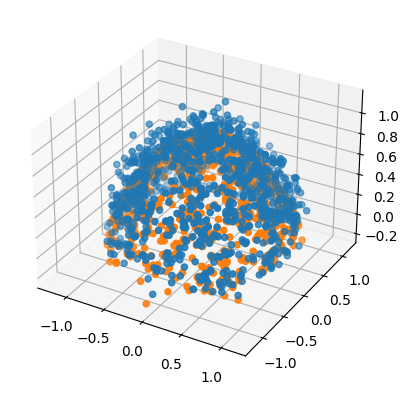

In [23]:
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(rec_data_train[:,0], rec_data_train[:,1], rec_data_train[:,2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [14]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [15]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

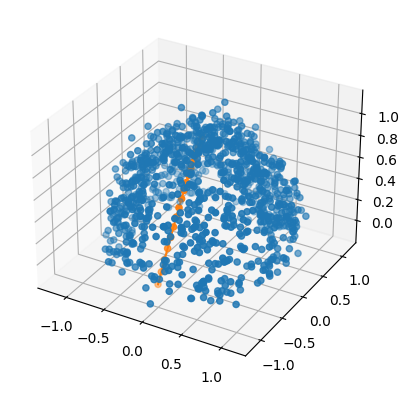

In [16]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [17]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([ 0.1522, -0.2543,  0.9776], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


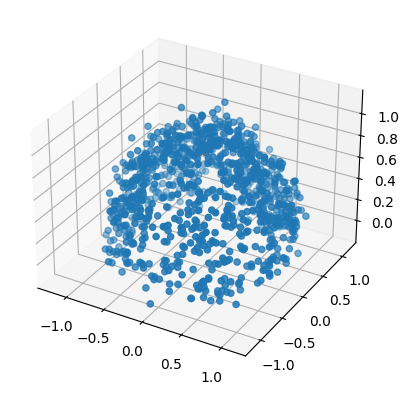

In [18]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [19]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [20]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

Computing rank 2 approximation on tangent space


AttributeError: 'int' object has no attribute 'cpu'

In [19]:
# compute approximations
approximations = l2_pga_solver.exp_x_Xi[2]

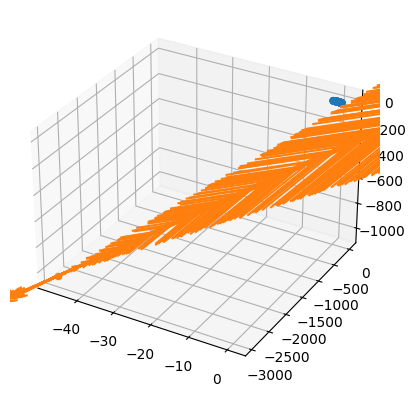

In [ ]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


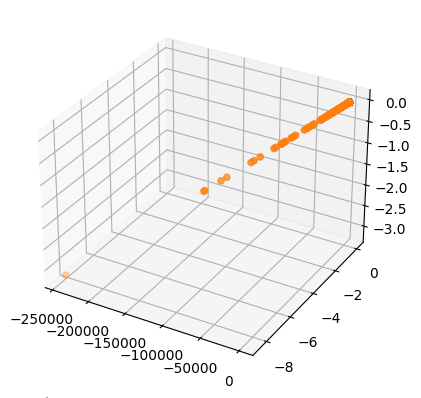

In [ ]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [22]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(2.5330e+11, grad_fn=<SumBackward0>)
